In [1]:
#Required libraries (uncomment to run)
#!pip install pennylane numpy pandas scipy dimod dwave-neal folium osmnx matplotlib mapclassify openpyxl

In [28]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

import pennylane as qml
from pennylane import numpy as pnp

import dimod
import neal

In [27]:
# ambulancesFull = pd.read_csv("Ambulances.csv")
# hospitalsFull = pd.read_csv("Hospitals.csv")

# ambulancesFull = ambulancesFull[["ambulance_id", "latitude", "longitude"]]
# hospitalsFull = hospitalsFull[["hospital_id", "latitude", "longitude"]]

# ambulances = ambulancesFull.head(2)
# hospitals = hospitalsFull.head(3)

# ambulances.reset_index(drop=True, inplace=True)
# hospitals.reset_index(drop=True, inplace=True)

# print(ambulances)

  ambulance_id  latitude  longitude
0          A01   33.7112    73.0579
1          A02   33.6824    73.0221


In [29]:
hospitalsAll = pd.read_excel("Datasheet.xlsx", sheet_name=0)
ambulancesAll = pd.read_excel("Datasheet.xlsx", sheet_name=1)
accidentsAll = pd.read_excel("Datasheet.xlsx", sheet_name=2)

hospitalsAll = hospitalsAll[["hospital_id", "latitude", "longitude"]]
ambulancesAll = ambulancesAll[["ambulance_id", "latitude", "longitude"]]
accidentsAll = accidentsAll[["accident_id", "latitude", "longitude"]]

hospitals = hospitalsAll.head(3)
ambulances = ambulancesAll.head(2)
accidents = accidentsAll.head(2)

hospitals.reset_index(drop=True, inplace=True)
ambulances.reset_index(drop=True, inplace=True)
accidents.reset_index(drop=True, inplace=True)

print(hospitals)
print(ambulances)
print(accidents)

  hospital_id   latitude  longitude
0         H01  33.702928  73.052461
1         H02  33.676297  73.066406
2         H03  33.652527  73.016214
  ambulance_id  latitude  longitude
0          A01   33.7112    73.0579
1          A02   33.6824    73.0221
  accident_id   latitude  longitude
0         X01  33.693824  73.033938
1         X02  33.695204  73.049784


In [9]:
# accidents = pd.DataFrame({
#     # "accident_id": ["X01", "X02", "X03", "X04"],
#     # "latitude": [33.70, 33.68, 33.72, 33.65],
#     # "longitude": [73.05, 73.02, 73.08, 73.00]
#     "accident_id": ["X01", "X02"],
#     "latitude": [33.70, 33.68],
#     "longitude": [73.05, 73.02]
# })

In [30]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))


In [31]:
num_acc = len(accidents)
num_amb = len(ambulances)
num_hosp = len(hospitals)

c = np.zeros((num_acc, num_amb))
d = np.zeros((num_acc, num_hosp))

for i in range(num_acc):
    for j in range(num_amb):
        c[i, j] = haversine(
            accidents.loc[i, "latitude"],
            accidents.loc[i, "longitude"],
            ambulances.loc[j, "latitude"],
            ambulances.loc[j, "longitude"]
        )

for i in range(num_acc):
    for k in range(num_hosp):
        d[i, k] = haversine(
            accidents.loc[i, "latitude"],
            accidents.loc[i, "longitude"],
            hospitals.loc[k, "latitude"],
            hospitals.loc[k, "longitude"]
        )


In [32]:
def x_index(i, j):
    return i * num_amb + j

def y_index(i, k):
    return num_acc * num_amb + i * num_hosp + k


In [33]:
n_vars = num_acc * num_amb + num_acc * num_hosp
Q = np.zeros((n_vars, n_vars))


In [34]:
for i in range(num_acc):
    for j in range(num_amb):
        Q[x_index(i, j), x_index(i, j)] += c[i, j]

for i in range(num_acc):
    for k in range(num_hosp):
        Q[y_index(i, k), y_index(i, k)] += d[i, k]


In [35]:
P = 100.0


In [36]:
for i in range(num_acc):
    idxs = [x_index(i, j) for j in range(num_amb)]
    for a in idxs:
        Q[a, a] += P
    for a in idxs:
        for b in idxs:
            if a != b:
                Q[a, b] += 2 * P
    for a in idxs:
        Q[a, a] -= 2 * P


In [37]:
for i in range(num_acc):
    idxs = [y_index(i, k) for k in range(num_hosp)]
    for a in idxs:
        Q[a, a] += P
    for a in idxs:
        for b in idxs:
            if a != b:
                Q[a, b] += 2 * P
    for a in idxs:
        Q[a, a] -= 2 * P


In [38]:
coeffs = []
ops = []

for i in range(n_vars):
    if Q[i, i] != 0:
        coeffs.append(Q[i, i] / 2)
        ops.append(qml.PauliZ(i))

for i in range(n_vars):
    for j in range(i+1, n_vars):
        if Q[i, j] != 0:
            coeffs.append(Q[i, j] / 4)
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))

H = qml.Hamiltonian(coeffs, ops)


In [39]:
dev = qml.device("default.qubit", wires=n_vars)

def qaoa_layer(gamma, beta):
    qml.qaoa.cost_layer(gamma, H)
    # Fix: Directly construct the mixer Hamiltonian using qml.Hamiltonian
    mixer_hamiltonian = qml.Hamiltonian([1.0] * n_vars, [qml.PauliX(i) for i in range(n_vars)])
    qml.qaoa.mixer_layer(beta, mixer_hamiltonian)

@qml.qnode(dev)
def circuit(params):
    for i in range(n_vars):
        qml.Hadamard(i)
    for g, b in params:
        qaoa_layer(g, b)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_vars)]

In [40]:
#Takes some time to run

p = 2
params = pnp.random.uniform(0, 2*np.pi, (p, 2), requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)

for _ in range(100):
    params = opt.step(lambda v: pnp.sum(circuit(v)), params)

print("Optimized parameters:", params)

Optimized parameters: [[2.9510912  4.53551915]
 [1.99632714 4.02644344]]


In [41]:
bqm = dimod.BinaryQuadraticModel(Q, "BINARY")
sampler = neal.SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, num_reads=1000)

print(sampleset.first)

Sample(sample={0: np.int8(0), 1: np.int8(1), 2: np.int8(1), 3: np.int8(0), 4: np.int8(1), 5: np.int8(0), 6: np.int8(0), 7: np.int8(1), 8: np.int8(0), 9: np.int8(0)}, energy=np.float64(-393.50796600893284), num_occurrences=np.int64(1))


In [42]:
assigned_ambulances = []
assigned_hospitals = []

solution_sample = sampleset.first.sample

for var_index, value in solution_sample.items():
    if value == 1:
        if var_index < num_acc * num_amb:
            # This is an ambulance assignment variable
            i = var_index // num_amb  # Accident index
            j = var_index % num_amb   # Ambulance index
            assigned_ambulances.append((i, j))
        else:
            # This is a hospital assignment variable
            relative_index = var_index - (num_acc * num_amb)
            i = relative_index // num_hosp  # Accident index
            k = relative_index % num_hosp   # Hospital index
            assigned_hospitals.append((i, k))

print("Assigned Ambulances (accident_idx, ambulance_idx):", assigned_ambulances)
print("Assigned Hospitals (accident_idx, hospital_idx):", assigned_hospitals)

Assigned Ambulances (accident_idx, ambulance_idx): [(0, 1), (1, 0)]
Assigned Hospitals (accident_idx, hospital_idx): [(0, 0), (1, 0)]


In [43]:
mapped_ambulance_assignments = []
mapped_hospital_assignments = []

for accident_idx, ambulance_idx in assigned_ambulances:
    accident_id = accidents.loc[accident_idx, "accident_id"]
    ambulance_id = ambulances.loc[ambulance_idx, "ambulance_id"]
    mapped_ambulance_assignments.append((accident_id, ambulance_id))

for accident_idx, hospital_idx in assigned_hospitals:
    accident_id = accidents.loc[accident_idx, "accident_id"]
    hospital_id = hospitals.loc[hospital_idx, "hospital_id"]
    mapped_hospital_assignments.append((accident_id, hospital_id))

print("Mapped Ambulance Assignments (accident_id, ambulance_id):", mapped_ambulance_assignments)
print("Mapped Hospital Assignments (accident_id, hospital_id):", mapped_hospital_assignments)

Mapped Ambulance Assignments (accident_id, ambulance_id): [('X01', 'A02'), ('X02', 'A01')]
Mapped Hospital Assignments (accident_id, hospital_id): [('X01', 'H01'), ('X02', 'H01')]


In [44]:
import folium

# Get the average coordinates to center the map
center_lat = accidents['latitude'].mean()
center_lon = accidents['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# Add markers for accidents
for idx, row in accidents.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Accident {row['accident_id']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)

# Add markers for ambulances
for idx, row in ambulances.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Ambulance {row['ambulance_id']}",
        icon=folium.Icon(color='blue', icon='truck')
    ).add_to(m)

# Add markers for hospitals
for idx, row in hospitals.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Hospital {row['hospital_id']}",
        icon=folium.Icon(color='green', icon='plus')
    ).add_to(m)

# Add lines for assigned ambulances to accidents
for acc_id, amb_id in mapped_ambulance_assignments:
    accident_coords = accidents[accidents['accident_id'] == acc_id][['latitude', 'longitude']].values[0]
    ambulance_coords = ambulances[ambulances['ambulance_id'] == amb_id][['latitude', 'longitude']].values[0]
    folium.PolyLine([ambulance_coords, accident_coords], color='purple', weight=2.5, opacity=1,
                    tooltip=f"Ambulance {amb_id} to Accident {acc_id}").add_to(m)

# Add lines for accidents to assigned hospitals
for acc_id, hosp_id in mapped_hospital_assignments:
    accident_coords = accidents[accidents['accident_id'] == acc_id][['latitude', 'longitude']].values[0]
    hospital_coords = hospitals[hospitals['hospital_id'] == hosp_id][['latitude', 'longitude']].values[0]
    folium.PolyLine([accident_coords, hospital_coords], color='orange', weight=2.5, opacity=1,
                    tooltip=f"Accident {acc_id} to Hospital {hosp_id}").add_to(m)

# Display the map
display(m)

In [45]:
print("--- Summary of Assignments ---")
for acc_id_amb, amb_id in mapped_ambulance_assignments:
    hospital_id = None
    for acc_id_hosp, hosp_id in mapped_hospital_assignments:
        if acc_id_amb == acc_id_hosp:
            hospital_id = hosp_id
            break
    if hospital_id:
        print(f"Ambulance {amb_id} goes to accident {acc_id_amb} and Hospital {hospital_id}")
    else:
        print(f"Ambulance {amb_id} goes to accident {acc_id_amb} but no hospital found.")

--- Summary of Assignments ---
Ambulance A02 goes to accident X01 and Hospital H01
Ambulance A01 goes to accident X02 and Hospital H01


In [46]:
import itertools

all_combinations = list(itertools.product([0, 1], repeat=n_vars))
print(f"Generated {len(all_combinations)} binary combinations.")

Generated 1024 binary combinations.


In [47]:
all_energies = []
for combination_tuple in all_combinations:
    combination = np.array(combination_tuple)
    # The energy for a given binary vector 'x' and QUBO matrix 'Q' is x.T @ Q @ x
    energy = combination.T @ Q @ combination
    all_energies.append((energy, combination_tuple))

print(f"Calculated energies for {len(all_energies)} combinations.")

Calculated energies for 1024 combinations.


In [48]:
import osmnx as ox

# Let's take the first assigned accident and hospital for demonstration
first_accident_id = mapped_ambulance_assignments[0][0]
first_hospital_id = mapped_hospital_assignments[0][1]

# Get coordinates for the first assigned accident and hospital
accident_loc = accidents[accidents['accident_id'] == first_accident_id].iloc[0]
hospital_loc = hospitals[hospitals['hospital_id'] == first_hospital_id].iloc[0]

origin_point = (accident_loc['latitude'], accident_loc['longitude'])
destination_point = (hospital_loc['latitude'], hospital_loc['longitude'])

# Create a graph from the area around the origin point
G = ox.graph_from_point(origin_point, dist=5000, network_type='drive')

# Impute travel time for edges if not already present
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Find the nearest network nodes to the origin and destination points
orign_node = ox.nearest_nodes(G, origin_point[1], origin_point[0])
destination_node = ox.nearest_nodes(G, destination_point[1], destination_point[0])

# Calculate the shortest path based on travel time
shortest_path = ox.shortest_path(G, orign_node, destination_node, weight='travel_time')

# Extract the edges (segments) of the shortest path into a GeoDataFrame
gdf = ox.routing.route_to_gdf(G, shortest_path)

print(f"Defined gdf for path from {first_accident_id} to {first_hospital_id} (consisting of {len(gdf)} segments).")
display(gdf.head())

Defined gdf for path from X01 to H01 (consisting of 37 segments).


,,,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,speed_kph,travel_time
u,v,key,,,,,,,,,,,
228918346,228917745,0,20495641,residential,NaN,NaN,اسٹریٹ 1,False,False,46.643084,"LINESTRING (73.03416 33.69374, 73.03392 33.693...",37.614943,4.464053
228917745,240486975,0,20495641,residential,NaN,NaN,اسٹریٹ 1,False,False,16.365514,"LINESTRING (73.03379 33.69402, 73.03368 33.69414)",37.614943,1.566288
240486975,240486655,0,20495641,residential,NaN,NaN,اسٹریٹ 1,False,False,24.948709,"LINESTRING (73.03368 33.69414, 73.03355 33.694...",37.614943,2.387757
240486655,228917035,0,20495641,residential,NaN,NaN,اسٹریٹ 1,False,False,16.266821,"LINESTRING (73.03352 33.69431, 73.03341 33.69443)",37.614943,1.556843
228917035,214791527,0,19965687,residential,NaN,NaN,اسٹریٹ 2,False,False,112.457305,"LINESTRING (73.03341 33.69443, 73.03373 33.694...",37.614943,10.762912


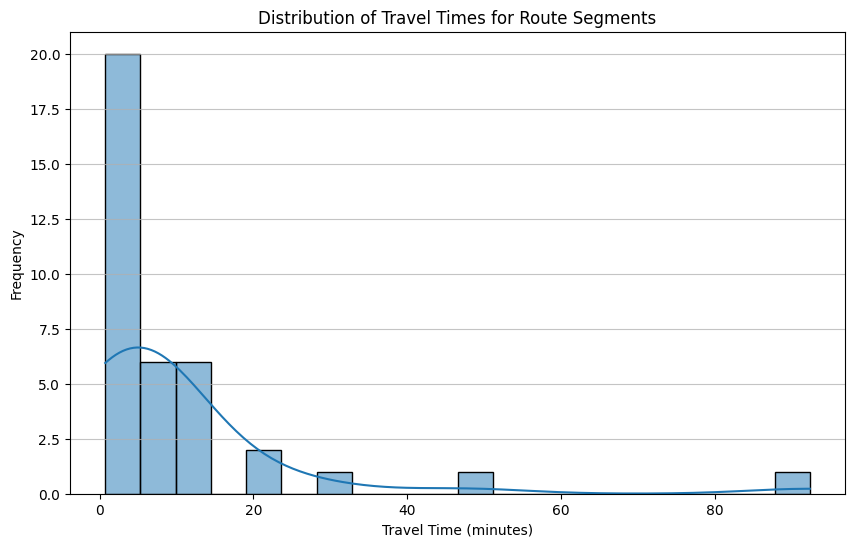

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(gdf['travel_time'], bins=20, kde=True)
plt.title('Distribution of Travel Times for Route Segments')
plt.xlabel('Travel Time (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [50]:
import osmnx as ox

# load city
place = "Islamabad, Pakistan"
G = ox.graph_from_place(place, network_type="drive")

# coordinates
kzh_lat, kzh_lon = 33.704514438166775, 73.05227435637488
# medical  coordinates
mdcl_lat, mdcl_lon = 33.653017, 72.957946


# fetch the nearest node w.r.t coordinates
kzh_node = ox.distance.nearest_nodes(G, kzh_lon, kzh_lat)
mdcl_node = ox.distance.nearest_nodes(G, mdcl_lon, mdcl_lat)

print("City Node: {kzh_node}, \
Medical Node: {mdcl_node}".format(
    kzh_node=kzh_node, mdcl_node=mdcl_node))

City Node: 247946514, Medical Node: 302494359


In [51]:
# Source - https://stackoverflow.com/a/77240651
# Posted by gboeing
# Retrieved 2026-02-07, License - CC BY-SA 4.0

#import osmnx as ox
#G2 = ox.graph_from_place("Piedmont, CA, USA", network_type="drive")
orig_coords = [33.704514438166775, 73.05227435637488]
dest_coords = [33.653017, 72.957946]
G2 = ox.add_edge_travel_times(ox.add_edge_speeds(G))

# first solve a shortest path by travel time
weight = "travel_time"
orig = kzh_node
dest = mdcl_node
route = ox.routing.shortest_path(G2, orig, dest, weight=weight)

# then find the length of that path
gdf = ox.routing.route_to_gdf(G2, route)
print(gdf["length"].sum())

14672.549258020154


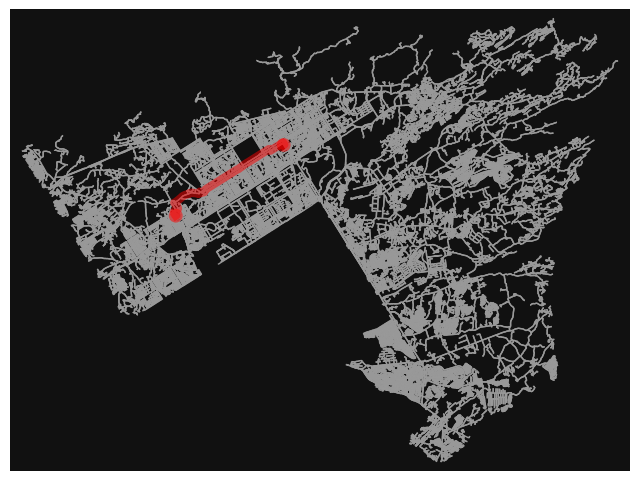

In [52]:
import osmnx as ox

place = "Islamabad, Pakistan" # Changed from "Thiruvananthapuram, Kerala" to match the nodes identified in the previous cell
G = ox.graph_from_place(place, network_type="drive")

# orgin node and destination node
orig, dest = 247946514, 302494359

# find shortest path
route_nodes = ox.routing.shortest_path(G, orig, dest, weight="length")

# plot the shortes path
fig, ax = ox.plot_graph_route(G, route_nodes, route_color="r",
                              route_linewidth=6, node_size=0)

In [54]:
def generate_multindex(route_nodes):
    multiindex_list = []
    # append the index to list
    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        multiindex_list.append((u, v, 0))
    return multiindex_list


# get edges from from above multidigraph
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

# generate multiindex based on generated shortest route
multiindex_list = generate_multindex(route_nodes)
# fetch edge details based on multi index list
shrt_gdf_edges = gdf_edges[gdf_edges.index.isin(multiindex_list)]
# plot the shortest route on map
shrt_gdf_edges.explore(color="red")

In [55]:
# Source - https://stackoverflow.com/a/77240651
# Posted by gboeing
# Retrieved 2026-02-07, License - CC BY-SA 4.0

orig = kzh_node
dest = mdcl_node
G = ox.add_edge_travel_times(ox.add_edge_speeds(G))

# first solve a shortest path by travel time
weight = "travel_time"
route = ox.routing.shortest_path(G, orig, dest, weight=weight)

# then find the length of that path
gdf_kzh_mdcl = ox.routing.route_to_gdf(G, route)
print(gdf_kzh_mdcl["length"].sum())

14672.549258020154


In [56]:
# Calculate and print the total travel time for the route
# The 'gdf' object from the previous step contains the travel time for each segment.
total_travel_time = gdf['travel_time'].sum()
print(f"Total estimated travel time for the shortest path: {total_travel_time:.2f} seconds")
print(f"Which is approximately {total_travel_time / 60:.2f} minutes")

Total estimated travel time for the shortest path: 627.76 seconds
Which is approximately 10.46 minutes


In [57]:
import folium
from shapely.ops import unary_union

def generate_multindex(route_nodes):
    multiindex_list = []
    # append the index to list
    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        # For MultiDiGraph, edges often have a key (default 0) if multiple edges exist between u and v
        multiindex_list.append((u, v, 0))
    return multiindex_list

# get edges from from above multidigraph
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

# generate multiindex based on generated shortest route (travel-time optimized route)
multiindex_list = generate_multindex(route)

# fetch edge details based on multi index list
# We need to filter gdf_edges more robustly to ensure we get the correct edges from the route.
# The index of gdf_edges is a MultiIndex (u, v, key).
# We need to match (u, v, key) from the route.

# A more robust way to select edges for the route is to use the `route_to_gdf` function
# which already did this in the previous step and stored it in `gdf`.
# We can directly use `gdf` for plotting.

# If we still want to use the generate_multindex function, we need to ensure the key matches.
# For simplicity, and as `gdf` already contains the route edges, we'll use `gdf` directly.

# Create a new column for formatted travel time
def format_travel_time(seconds):
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours > 0:
        return f"{int(hours)}h {int(minutes)}m {int(seconds)}s"
    elif minutes > 0:
        return f"{int(minutes)}m {int(seconds)}s"
    else:
        return f"{int(seconds)}s"

gdf['travel_time_formatted'] = gdf['travel_time'].apply(format_travel_time)

# Create a column for the total travel time string to be used in tooltips and on-path label
total_travel_time_str = f"Total Travel Time: {total_travel_time/60:.2f} minutes ({total_travel_time:.0f} seconds)"
gdf['total_travel_time_tooltip'] = total_travel_time_str

# plot the shortest route on map, using gdf (which already has travel_time)
# and displaying 'total_travel_time_tooltip' as a tooltip.
shrt_gdf_edges_interactive = gdf.explore(
    color="red",
    tooltip=['total_travel_time_tooltip'], # Display total travel_time as tooltip
    tiles="OpenStreetMap" # Optional: change base map style
)

# Add a title to the map
title_html = f'''
             <h3 align="center" style="font-size:16px"><b>Shortest Path (Travel Time Optimized)<br>{total_travel_time_str}</b></h3>
             '''
shrt_gdf_edges_interactive.get_root().html.add_child(folium.Element(title_html))

# Add the total travel time directly on the path
# Combine all geometries in gdf into a single MultiLineString or LineString
all_route_geometries = gdf['geometry'].tolist()
if len(all_route_geometries) > 0:
    united_path = unary_union(all_route_geometries)
    # Get the centroid of the united path
    centroid = united_path.centroid
    centroid_coords = (centroid.y, centroid.x) # (lat, lon) for folium

    # Create a DivIcon for the label
    div_icon = folium.features.DivIcon(
        icon_size=(200, 30), # Adjust size as needed
        icon_anchor=(100, 15), # Adjust anchor to center the text
        html=f'''<div style="font-size: 12pt; color: black; background-color: white; padding: 5px; border-radius: 5px; font-weight: bold;">{total_travel_time_str}</div>''',
    )

    # Add a marker with this icon at the centroid
    folium.Marker(location=centroid_coords, icon=div_icon).add_to(shrt_gdf_edges_interactive)

shrt_gdf_edges_interactive